#**HW1**
Data Analytics

Authors: Najafizadeh, Hatami, Ardi

#Import Necessary Library

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torch.optim as optim
import torchvision
from torch.optim.lr_scheduler import StepLR
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import transforms
from PIL import Image
from google.colab import drive
import glob
from pathlib import Path

In [3]:
# run this to see all the outputs below each cell, not only the last instruction 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [4]:
# mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


#Part A

##Part A-1

In [5]:
# Load labels into a pandas DataFrame
labels_df = pd.read_csv('/content/drive/MyDrive/data/ByteToImage/trainLabels.csv')

# Path to the folder containing the images
images_dir = '/content/drive/MyDrive/data/ByteToImage/ByteToImage'

# Get list of image paths and labels
# X = [os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith('.png')]
X = glob.glob('/content/drive/MyDrive/data/ByteToImage/ByteToImage/*.png')

In [6]:
y = []
import pandas
df = pandas.read_csv('/content/drive/MyDrive/data/ByteToImage/trainLabels.csv')
for img in X :
    id = df[df['Id'] == str(Path(img).stem.__str__())]['Class'].iloc[0]
    y.append(id)

In [7]:
# Split data into training, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=40)

In [8]:
# Define a custom function to load and transform data
def load_and_transform_data(X, y, transform):
    data = []
    for i in range(len(X)):
        img_path = X[i]
        img = Image.open(img_path).convert('RGB')
        if transform is not None:
            img = transform(img)
        label = y[i]-1 # labels are in [1,9], should be in [0,8]
        data.append((img, label))
    return data

In [9]:
# Load images and apply transformations # also you can use transforms.Resize((64, 64))
data_transforms = transforms.Compose([transforms.Grayscale(num_output_channels=1),
                                      transforms.ToTensor(),
                                      transforms.Normalize(mean=(0.5, ), std=(0.5, ))])

train_data = load_and_transform_data(X_train, y_train, transform=data_transforms)
val_data = load_and_transform_data(X_val, y_val, transform=data_transforms)
test_data = load_and_transform_data(X_test, y_test, transform=data_transforms)

batch_size=128

trainloader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
valloader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)
testloader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

print("Training set size:", len(train_data))
print("Validation set size:", len(val_data))
print("Test set size:", len(test_data))
print(type(train_data), type(train_data[0]), type(train_data[0][0]))
print("image shape:", train_data[0][0].shape)
print("label type:", type(train_data[0][1]))
print(train_data[0][0].shape)


Training set size: 8688
Validation set size: 1086
Test set size: 1086
<class 'list'> <class 'tuple'> <class 'torch.Tensor'>
image shape: torch.Size([1, 32, 32])
label type: <class 'numpy.int64'>
torch.Size([1, 32, 32])


In [19]:
print("GPU available: {}".format(torch.cuda.is_available()))
if torch.cuda.is_available():
  device = 'cuda' 
else:
  device = 'cpu' 

GPU available: True


ParametricCNN with 4 CNN and 3 fully connected

In [20]:
class ParametricCNN(nn.Module):
    def __init__(self, num_classes=9, lr=0.001, reg=0.001, device='cpu'):
        super(ParametricCNN, self).__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layer
        self.fc1 = nn.Linear(256 * 8 * 8 , 256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, num_classes)

        # Hyperparameters
        self.lr = lr
        self.reg = reg
        self.num_classes = num_classes
        self.device = device

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool2(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = self.pool4(F.relu(self.conv4(x)))
        x = x.view(-1, 256 * 8 * 8 )
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim=1)
        return x
    def configure_optimizers(self):
        optimizer = optim.SGD(self.parameters(), lr=self.lr, weight_decay=self.reg)
        return optimizer


In [27]:
class ParametricCNN_dropout (nn.Module):
    def __init__(self, num_classes=9, lr=0.001, reg=0.001, device='cpu'):
        super(ParametricCNN_dropout, self).__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Dropout
        self.dropout1 = nn.Dropout(p=0.2)
        self.dropout2 = nn.Dropout(p=0.2)
        self.dropout3 = nn.Dropout(p=0.2)
        self.dropout4 = nn.Dropout(p=0.2)

        # Fully connected layer
        self.fc1 = nn.Linear(256 * 8 * 8 , 256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, num_classes)

        # Hyperparameters
        self.lr = lr
        self.reg = reg
        self.num_classes = num_classes
        self.device = device

    def forward(self, x):
        x = F.relu(self.dropout1(self.conv1(x)))
        x = self.pool2(F.relu(self.dropout2(self.conv2(x))))
        x = F.relu(self.dropout3(self.conv3(x)))
        x = self.pool4(F.relu(self.dropout4(self.conv4(x))))
        x = x.view(-1, 256 * 8 * 8 )
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim=1)
        return x
    def configure_optimizers(self):
        optimizer = optim.SGD(self.parameters(), lr=self.lr, weight_decay=self.reg)
        return optimizer


In [22]:
class ParametricCNN_batch(nn.Module):
    def __init__(self, num_classes=9, lr=0.001, reg=0.001, device='cpu'):
        super(ParametricCNN_batch, self).__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(num_features=32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn2 = nn.BatchNorm2d(num_features=64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(num_features=128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn4 = nn.BatchNorm2d(num_features=256)


        # Fully connected layer
        self.fc1 = nn.Linear(256 * 8 * 8 , 256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, num_classes)

        # Hyperparameters
        self.lr = lr
        self.reg = reg
        self.num_classes = num_classes
        self.device = device

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        x = x.view(-1, 256 * 8 * 8 )
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim=1)
        return x
    def configure_optimizers(self):
        optimizer = optim.SGD(self.parameters(), lr=self.lr, weight_decay=self.reg)
        return optimizer


ParametricCNN with 6 CNN and 3 fully connected and have batch normalization

# Part F

# Part F-1

In [30]:
net_lr_01 = ParametricCNN_batch(lr=0.1,reg = 0.005, device=device).train()
net_lr_01.to(device)

optimizer = net_lr_01.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 100

epoch_log_01 = []
loss_log_01 = []
train_accuracy_log_01 = []
test_accuracy_log_01 = []
validation_accuracy_log_01 = []


for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    net_lr_01 = net_lr_01.train()

    for i, data in enumerate(trainloader):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_01(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 
    net_lr_01 = net_lr_01.eval()
    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)
            

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 
    net_lr_01 = net_lr_01.eval()
    with torch.no_grad():
        for data in valloader:
            images, labels = data
            # print(images[0])
            # print(images[1])
            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')

    epoch_log_01.append(epoch_num)
    loss_log_01.append(actual_loss)
    train_accuracy_log_01.append(train_accuracy)
    validation_accuracy_log_01.append(validation_accuracy)
    test_accuracy_log_01.append(test_accuracy)

print('Finished Training')
del net_lr_01

ParametricCNN_batch(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linea

Starting Epoch: 1...
Loss: 1.716
Train Accuracy = 72.905%
Validation Accuracy = 69.890%
Test Accuracy = 74.586%
Starting Epoch: 2...
Loss: 1.585
Train Accuracy = 79.823%
Validation Accuracy = 76.427%
Test Accuracy = 81.031%
Starting Epoch: 3...
Loss: 1.584
Train Accuracy = 80.410%
Validation Accuracy = 77.716%
Test Accuracy = 81.676%
Starting Epoch: 4...
Loss: 1.566
Train Accuracy = 80.882%
Validation Accuracy = 77.624%
Test Accuracy = 82.689%
Starting Epoch: 5...
Loss: 1.529
Train Accuracy = 86.924%
Validation Accuracy = 83.702%
Test Accuracy = 86.924%
Starting Epoch: 6...
Loss: 1.497
Train Accuracy = 90.228%
Validation Accuracy = 87.753%
Test Accuracy = 90.792%
Starting Epoch: 7...
Loss: 1.483
Train Accuracy = 89.814%
Validation Accuracy = 87.201%
Test Accuracy = 90.147%
Starting Epoch: 8...
Loss: 1.475
Train Accuracy = 91.126%
Validation Accuracy = 88.950%
Test Accuracy = 91.805%
Starting Epoch: 9...
Loss: 1.472
Train Accuracy = 90.976%
Validation Accuracy = 88.766%
Test Accuracy = 

Text(0.5, 1.0, 'train, validation and test accuracy of cnn with batch normalization ')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

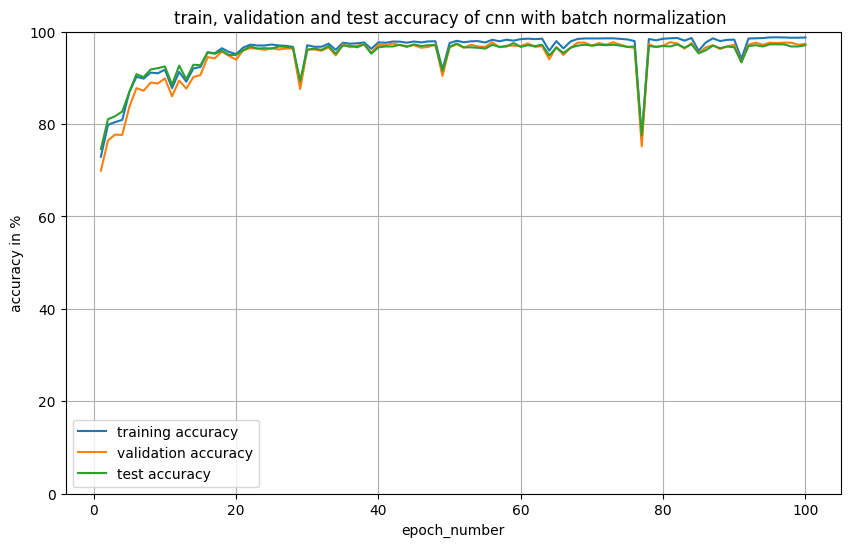

In [31]:
import matplotlib.pyplot as plt

#plotting train, validation and test accuracies for ParametricCNN with batch
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_01, train_accuracy_log_01, label='training accuracy')
ax.plot(epoch_log_01, validation_accuracy_log_01, label='validation accuracy')
ax.plot(epoch_log_01, test_accuracy_log_01, label='test accuracy')

ax.set_title('train, validation and test accuracy of cnn with batch normalization ')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

In [32]:
net_lr_01 = ParametricCNN_dropout(lr=0.1,reg = 0.005, device=device).train()
net_lr_01.to(device)

optimizer = net_lr_01.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 100

epoch_log_01 = []
loss_log_01 = []
train_accuracy_log_01 = []
test_accuracy_log_01 = []
validation_accuracy_log_01 = []


for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    net_lr_01 = net_lr_01.train()

    for i, data in enumerate(trainloader):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_01(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 
    net_lr_01 = net_lr_01.eval()
    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)
            

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 
    net_lr_01 = net_lr_01.eval()
    with torch.no_grad():
        for data in valloader:
            images, labels = data
            # print(images[0])
            # print(images[1])
            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')

    epoch_log_01.append(epoch_num)
    loss_log_01.append(actual_loss)
    train_accuracy_log_01.append(train_accuracy)
    validation_accuracy_log_01.append(validation_accuracy)
    test_accuracy_log_01.append(test_accuracy)

print('Finished Training')
del net_lr_01

ParametricCNN_dropout(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.2, inplace=False)
  (dropout2): Dropout(p=0.2, inplace=False)
  (dropout3): Dropout(p=0.2, inplace=False)
  (dropout4): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Loss: 2.196
Train Accuracy = 22.629%
Validation Accuracy = 23.204%
Test Accuracy = 23.941%
Starting Epoch: 2...
Loss: 2.154
Train Accuracy = 39.307%
Validation Accuracy = 37.661%
Test Accuracy = 42.357%
Starting Epoch: 3...
Loss: 2.081
Train Accuracy = 22.629%
Validation Accuracy = 23.204%
Test Accuracy = 23.941%
Starting Epoch: 4...
Loss: 1.987
Train Accuracy = 46.812%
Validation Accuracy = 45.856%
Test Accuracy = 49.355%
Starting Epoch: 5...
Loss: 1.894
Train Accuracy = 48.423%
Validation Accuracy = 48.158%
Test Accuracy = 51.381%
Starting Epoch: 6...
Loss: 1.891
Train Accuracy = 48.354%
Validation Accuracy = 47.882%
Test Accuracy = 51.013%
Starting Epoch: 7...
Loss: 1.891
Train Accuracy = 48.354%
Validation Accuracy = 47.882%
Test Accuracy = 51.013%
Starting Epoch: 8...
Loss: 1.891
Train Accuracy = 48.504%
Validation Accuracy = 48.250%
Test Accuracy = 51.473%
Starting Epoch: 9...
Loss: 1.890
Train Accuracy = 48.400%
Validation Accuracy = 48.158%
Test Accuracy = 

Text(0.5, 1.0, 'train, validation and test accuracy of cnn with dropout = 0.2 ')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

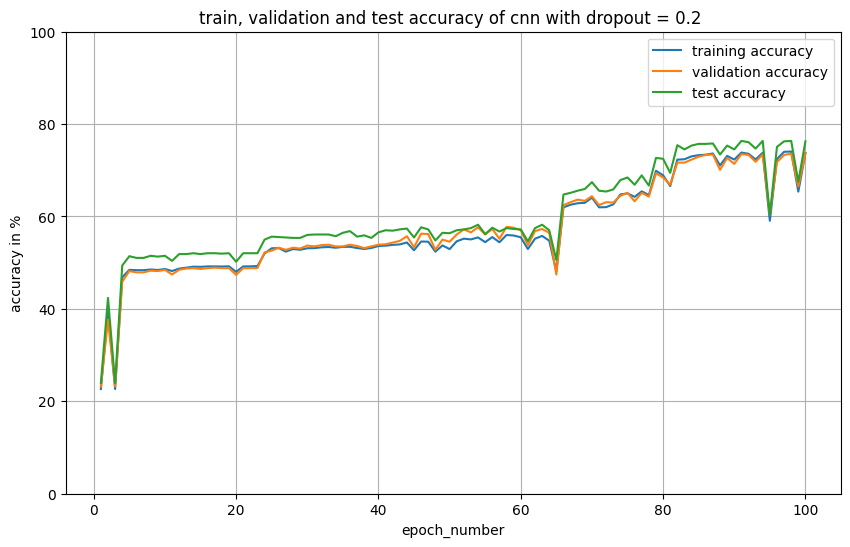

In [33]:
import matplotlib.pyplot as plt

#plotting train, validation and test accuracies for ParametricCNN with batch
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_01, train_accuracy_log_01, label='training accuracy')
ax.plot(epoch_log_01, validation_accuracy_log_01, label='validation accuracy')
ax.plot(epoch_log_01, test_accuracy_log_01, label='test accuracy')

ax.set_title('train, validation and test accuracy of cnn with dropout = 0.2 ')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

In [36]:
class ParametricCNN_batch_dropout(nn.Module):
    def __init__(self, num_classes=9, lr=0.001, reg=0.001, device='cpu'):
        super(ParametricCNN_batch_dropout, self).__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(num_features=32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn2 = nn.BatchNorm2d(num_features=64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(num_features=128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn4 = nn.BatchNorm2d(num_features=256)

        # Dropout
        self.dropout1 = nn.Dropout(p=0.2)
        self.dropout2 = nn.Dropout(p=0.2)
        self.dropout3 = nn.Dropout(p=0.2)
        self.dropout4 = nn.Dropout(p=0.2)


        # Fully connected layer
        self.fc1 = nn.Linear(256 * 8 * 8 , 256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, num_classes)

        # Hyperparameters
        self.lr = lr
        self.reg = reg
        self.num_classes = num_classes
        self.device = device

    def forward(self, x):
        x = F.relu(self.dropout1(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.dropout2(self.bn2(self.conv2(x)))))
        x = F.relu(self.dropout3(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.dropout4(self.bn4(self.conv4(x)))))
        x = x.view(-1, 256 * 8 * 8 )
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim=1)
        return x
    def configure_optimizers(self):
        optimizer = optim.SGD(self.parameters(), lr=self.lr, weight_decay=self.reg)
        return optimizer


In [37]:
net_lr_01 = ParametricCNN_batch_dropout(lr=0.1,reg = 0.005, device=device).train()
net_lr_01.to(device)

optimizer = net_lr_01.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 100

epoch_log_01 = []
loss_log_01 = []
train_accuracy_log_01 = []
test_accuracy_log_01 = []
validation_accuracy_log_01 = []


for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    net_lr_01 = net_lr_01.train()

    for i, data in enumerate(trainloader):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_01(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 
    net_lr_01 = net_lr_01.eval()
    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)
            

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 
    net_lr_01 = net_lr_01.eval()
    with torch.no_grad():
        for data in valloader:
            images, labels = data
            # print(images[0])
            # print(images[1])
            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')

    epoch_log_01.append(epoch_num)
    loss_log_01.append(actual_loss)
    train_accuracy_log_01.append(train_accuracy)
    validation_accuracy_log_01.append(validation_accuracy)
    test_accuracy_log_01.append(test_accuracy)

print('Finished Training')
del net_lr_01

ParametricCNN_batch_dropout(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (dropout2): Dropout(p=0.2, inplace=False)
  (dropout3): Dropout(p=0.2, inplace=False)

Starting Epoch: 1...
Loss: 1.791
Train Accuracy = 68.174%
Validation Accuracy = 65.378%
Test Accuracy = 70.258%
Starting Epoch: 2...
Loss: 1.638
Train Accuracy = 75.863%
Validation Accuracy = 72.468%
Test Accuracy = 77.348%
Starting Epoch: 3...
Loss: 1.592
Train Accuracy = 78.108%
Validation Accuracy = 74.494%
Test Accuracy = 80.295%
Starting Epoch: 4...
Loss: 1.570
Train Accuracy = 80.410%
Validation Accuracy = 77.072%
Test Accuracy = 82.136%
Starting Epoch: 5...
Loss: 1.557
Train Accuracy = 81.664%
Validation Accuracy = 78.085%
Test Accuracy = 82.597%
Starting Epoch: 6...
Loss: 1.534
Train Accuracy = 85.843%
Validation Accuracy = 83.610%
Test Accuracy = 87.017%
Starting Epoch: 7...
Loss: 1.510
Train Accuracy = 87.569%
Validation Accuracy = 85.635%
Test Accuracy = 88.306%
Starting Epoch: 8...
Loss: 1.506
Train Accuracy = 87.201%
Validation Accuracy = 85.543%
Test Accuracy = 87.845%
Starting Epoch: 9...
Loss: 1.483
Train Accuracy = 89.802%
Validation Accuracy = 87.845%
Test Accuracy = 

Text(0.5, 1.0, 'train, validation and test accuracy of cnn with batch norm.. then dropout = 0.2 ')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

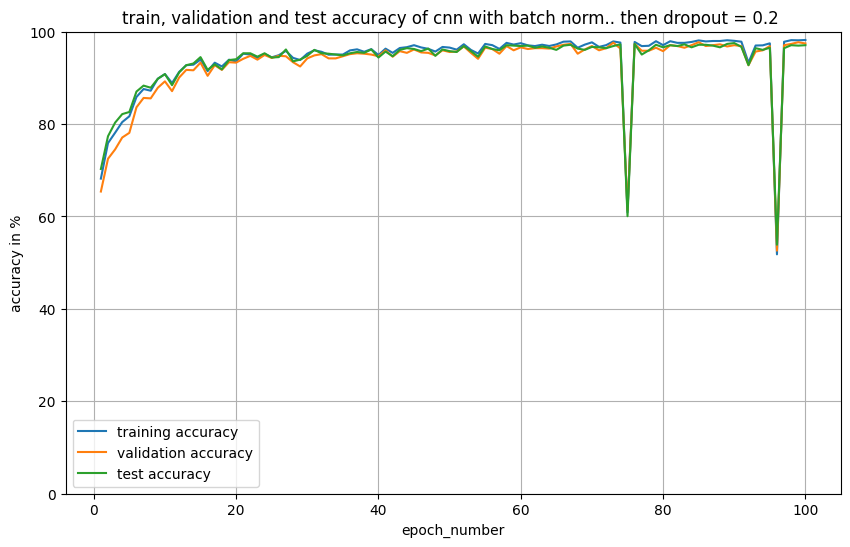

In [38]:
import matplotlib.pyplot as plt

#plotting train, validation and test accuracies for ParametricCNN 
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_01, train_accuracy_log_01, label='training accuracy')
ax.plot(epoch_log_01, validation_accuracy_log_01, label='validation accuracy')
ax.plot(epoch_log_01, test_accuracy_log_01, label='test accuracy')

ax.set_title('train, validation and test accuracy of cnn with batch norm.. then dropout = 0.2 ')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

In [39]:
class ParametricCNN_dropout_batch(nn.Module):
    def __init__(self, num_classes=9, lr=0.001, reg=0.001, device='cpu'):
        super(ParametricCNN_dropout_batch, self).__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(num_features=32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn2 = nn.BatchNorm2d(num_features=64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(num_features=128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn4 = nn.BatchNorm2d(num_features=256)

        # Dropout
        self.dropout1 = nn.Dropout(p=0.2)
        self.dropout2 = nn.Dropout(p=0.2)
        self.dropout3 = nn.Dropout(p=0.2)
        self.dropout4 = nn.Dropout(p=0.2)


        # Fully connected layer
        self.fc1 = nn.Linear(256 * 8 * 8 , 256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, num_classes)

        # Hyperparameters
        self.lr = lr
        self.reg = reg
        self.num_classes = num_classes
        self.device = device

    def forward(self, x):
        x = F.relu(self.bn1(self.dropout1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.dropout2(self.conv2(x)))))
        x = F.relu(self.bn3(self.dropout3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.dropout4(self.conv4(x)))))
        x = x.view(-1, 256 * 8 * 8 )
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim=1)
        return x
    def configure_optimizers(self):
        optimizer = optim.SGD(self.parameters(), lr=self.lr, weight_decay=self.reg)
        return optimizer


In [40]:
net_lr_01 = ParametricCNN_dropout_batch(lr=0.1,reg = 0.005, device=device).train()
net_lr_01.to(device)

optimizer = net_lr_01.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 100

epoch_log_01 = []
loss_log_01 = []
train_accuracy_log_01 = []
test_accuracy_log_01 = []
validation_accuracy_log_01 = []


for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    net_lr_01 = net_lr_01.train()

    for i, data in enumerate(trainloader):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_01(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 
    net_lr_01 = net_lr_01.eval()
    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)
            

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 
    net_lr_01 = net_lr_01.eval()
    with torch.no_grad():
        for data in valloader:
            images, labels = data
            # print(images[0])
            # print(images[1])
            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')

    epoch_log_01.append(epoch_num)
    loss_log_01.append(actual_loss)
    train_accuracy_log_01.append(train_accuracy)
    validation_accuracy_log_01.append(validation_accuracy)
    test_accuracy_log_01.append(test_accuracy)

print('Finished Training')
del net_lr_01

ParametricCNN_dropout_batch(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (dropout2): Dropout(p=0.2, inplace=False)
  (dropout3): Dropout(p=0.2, inplace=False)

Starting Epoch: 1...
Loss: 1.835
Train Accuracy = 59.185%
Validation Accuracy = 56.354%
Test Accuracy = 62.155%
Starting Epoch: 2...
Loss: 1.645
Train Accuracy = 76.266%
Validation Accuracy = 72.007%
Test Accuracy = 77.440%
Starting Epoch: 3...
Loss: 1.605
Train Accuracy = 74.563%
Validation Accuracy = 69.982%
Test Accuracy = 75.599%
Starting Epoch: 4...
Loss: 1.596
Train Accuracy = 77.889%
Validation Accuracy = 74.217%
Test Accuracy = 79.650%
Starting Epoch: 5...
Loss: 1.591
Train Accuracy = 78.246%
Validation Accuracy = 74.494%
Test Accuracy = 79.926%
Starting Epoch: 6...
Loss: 1.576
Train Accuracy = 81.469%
Validation Accuracy = 78.361%
Test Accuracy = 82.965%
Starting Epoch: 7...
Loss: 1.560
Train Accuracy = 82.297%
Validation Accuracy = 78.085%
Test Accuracy = 83.333%
Starting Epoch: 8...
Loss: 1.549
Train Accuracy = 82.274%
Validation Accuracy = 78.545%
Test Accuracy = 84.715%
Starting Epoch: 9...
Loss: 1.534
Train Accuracy = 84.024%
Validation Accuracy = 80.203%
Test Accuracy = 

Text(0.5, 1.0, 'train, validation and test accuracy of cnn with dropout = 0.2 then batch norm.. ')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

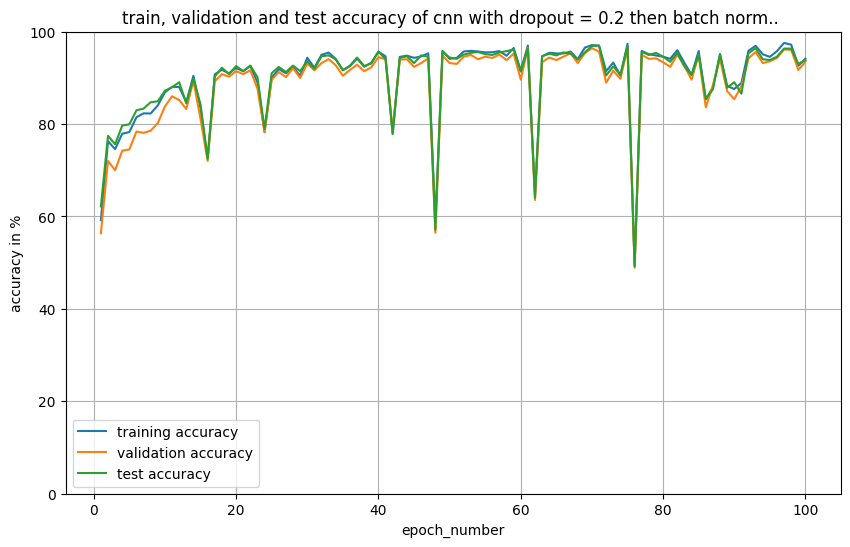

In [41]:
import matplotlib.pyplot as plt

#plotting train, validation and test accuracies for ParametricCNN 
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_01, train_accuracy_log_01, label='training accuracy')
ax.plot(epoch_log_01, validation_accuracy_log_01, label='validation accuracy')
ax.plot(epoch_log_01, test_accuracy_log_01, label='test accuracy')

ax.set_title('train, validation and test accuracy of cnn with dropout = 0.2 then batch norm.. ')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

In [44]:
class ParametricCNN_Deep(nn.Module):
    def __init__(self, num_classes=9, lr=0.001, reg=0.001, device='cpu'):
        super(ParametricCNN_Deep, self).__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(num_features=32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn2 = nn.BatchNorm2d(num_features=64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(num_features=128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn4 = nn.BatchNorm2d(num_features=256)
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn5 = nn.BatchNorm2d(num_features=512)
        self.conv6 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.pool6 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bn6 = nn.BatchNorm2d(num_features=512)
        # Fully connected layer
        self.fc1 = nn.Linear(2*2*512, 256)
        self.bn7 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 64)
        self.bn8 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, num_classes)

        # Dropout
        self.dropout1 = nn.Dropout(p=0.2)
        self.dropout2 = nn.Dropout(p=0.2)
        self.dropout3 = nn.Dropout(p=0.2)
        self.dropout4 = nn.Dropout(p=0.2)
        self.dropout5 = nn.Dropout(p=0.2)
        self.dropout6 = nn.Dropout(p=0.2)

        # Hyperparameters
        self.lr = lr
        self.reg = reg
        self.num_classes = num_classes
        self.device = device

    def forward(self, x):
        x = F.relu(self.bn1(self.dropout1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.dropout2(self.conv2(x)))))
        x = F.relu(self.bn3(self.dropout3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.dropout4(self.conv4(x)))))
        x = self.pool5(F.relu(self.bn5(self.dropout5(self.conv5(x)))))
        x = self.pool6(F.relu(self.bn6(self.dropout6(self.conv6(x)))))
        x = x.view(-1, 512*2*2)
        x = F.relu(self.bn7(self.fc1(x)))
        x = F.relu(self.bn8(self.fc2(x)))
        x = F.softmax(self.fc3(x), dim=1)
        return x
    def configure_optimizers(self):
        optimizer = optim.SGD(self.parameters(), lr=self.lr, weight_decay=self.reg)
        return optimizer

In [46]:
net_lr_01 = ParametricCNN_Deep(lr=0.05,reg = 0.005, device=device).train()
net_lr_01.to(device)

optimizer = net_lr_01.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 100

epoch_log_01 = []
loss_log_01 = []
train_accuracy_log_01 = []
test_accuracy_log_01 = []
validation_accuracy_log_01 = []


for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    net_lr_01 = net_lr_01.train()

    for i, data in enumerate(trainloader):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_lr_01(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 
    net_lr_01 = net_lr_01.eval()
    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)
            

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 
    net_lr_01 = net_lr_01.eval()
    with torch.no_grad():
        for data in valloader:
            images, labels = data
            # print(images[0])
            # print(images[1])
            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_lr_01(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')

    epoch_log_01.append(epoch_num)
    loss_log_01.append(actual_loss)
    train_accuracy_log_01.append(train_accuracy)
    validation_accuracy_log_01.append(validation_accuracy)
    test_accuracy_log_01.append(test_accuracy)

print('Finished Training')
del net_lr_01

ParametricCNN_Deep(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool5): MaxPool2d(kernel_size=2, stride=2, padding=0, dila

Starting Epoch: 1...
Loss: 1.816
Train Accuracy = 27.083%
Validation Accuracy = 26.335%
Test Accuracy = 29.006%
Starting Epoch: 2...
Loss: 1.618
Train Accuracy = 29.731%
Validation Accuracy = 29.558%
Test Accuracy = 31.584%
Starting Epoch: 3...
Loss: 1.570
Train Accuracy = 38.973%
Validation Accuracy = 36.556%
Test Accuracy = 39.963%
Starting Epoch: 4...
Loss: 1.552
Train Accuracy = 43.934%
Validation Accuracy = 41.344%
Test Accuracy = 43.923%
Starting Epoch: 5...
Loss: 1.542
Train Accuracy = 49.586%
Validation Accuracy = 47.422%
Test Accuracy = 50.645%
Starting Epoch: 6...
Loss: 1.531
Train Accuracy = 57.551%
Validation Accuracy = 54.236%
Test Accuracy = 58.103%
Starting Epoch: 7...
Loss: 1.514
Train Accuracy = 63.260%
Validation Accuracy = 59.576%
Test Accuracy = 62.891%
Starting Epoch: 8...
Loss: 1.498
Train Accuracy = 68.980%
Validation Accuracy = 65.562%
Test Accuracy = 69.705%
Starting Epoch: 9...
Loss: 1.488
Train Accuracy = 70.960%
Validation Accuracy = 67.219%
Test Accuracy = 

Text(0.5, 1.0, 'train, validation and test accuracy of cnn with dropout = 0.2 then batch norm.. ')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

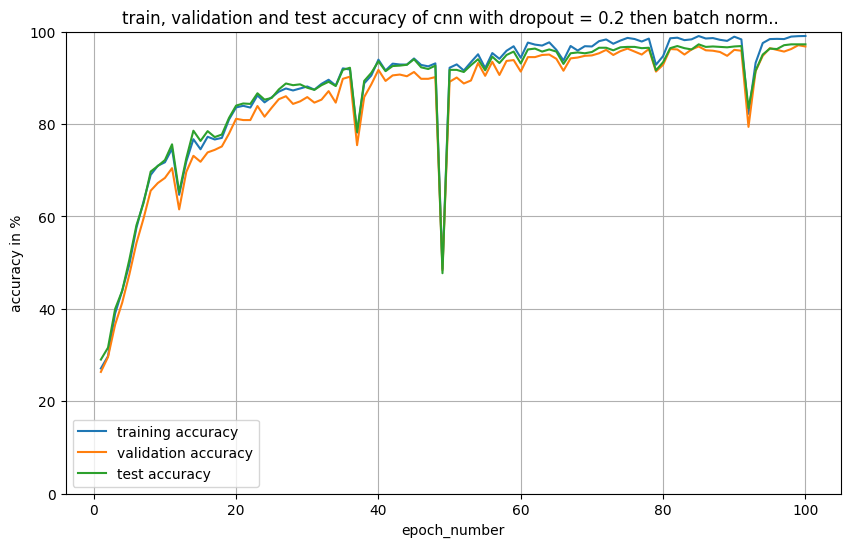

In [47]:
import matplotlib.pyplot as plt

#plotting train, validation and test accuracies for ParametricCNN 
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_01, train_accuracy_log_01, label='training accuracy')
ax.plot(epoch_log_01, validation_accuracy_log_01, label='validation accuracy')
ax.plot(epoch_log_01, test_accuracy_log_01, label='test accuracy')

ax.set_title('train, validation and test accuracy of cnn with dropout = 0.2 then batch norm.. ')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()